In [39]:
# =============================================================================
# SÜPER LİG GİZLİ DEĞERLİ OYUNCU ANALİZİ
# =============================================================================
 
# =============================================================================
# BÖLÜM 1: KURULUM
# =============================================================================
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import requests
import unicodedata
import warnings
from bs4 import BeautifulSoup
from thefuzz import process
 
warnings.filterwarnings("ignore")
 
HEADERS = {
    "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/120.0.0.0 Safari/537.36",
    "Accept-Language": "tr-TR,tr;q=0.9",
    "Referer": "https://www.transfermarkt.com.tr/"
}
 
# Süper Lig takımları ve Transfermarkt ID'leri
TAKIMLAR = {
    "Galatasaray":       141,
    "Fenerbahce":         36,
    "Trabzonspor":       449,
    "Besiktas":          114,
    "Goztepe":          1467,
    "Basaksehir":       6890,
    "Samsunspor":        152,
    "Kocaelispor":       120,
    "Gaziantep-fk":     2832,
    "caykur-rizespor":   126,
    "Alanyaspor":      11282,
    "Konyaspor":        2293,
    "Genclerbirligi":    820,
    "Kasimpasa":       10484,
    "Antalyaspor":       589,
    "Eyupspor":         7160,
    "Kayserispor":      3205,
    "Fatih-Karagumruk": 6646,
}
 
 
def isim_temizle(isim):
    """Türkçe ve özel karakterleri Latin karşılıklarına çevirelim."""
    isim = str(isim).strip().lower()
    isim = unicodedata.normalize("NFKD", isim)
    isim = "".join(c for c in isim if not unicodedata.combining(c))
    return isim
 
 
def deger_donustur(deger):
    """'18.00 mil. €' veya '300 bin €' formatındaki değerleri float'a çevirelim."""
    if deger == "-" or pd.isna(deger):
        return np.nan
    deger = str(deger).replace(" ", "").replace("€", "")
    if "mil." in deger:
        return float(deger.replace("mil.", "")) * 1_000_000
    elif "bin" in deger:
        return float(deger.replace("bin", "")) * 1_000
    return np.nan
 
 
def performans_skoru(row):
    """
    Pozisyona göre ağırlıklı 90dk başına gol+asist skoru hesaplayalım.
    Forvet: gol ağırlıklı (0.7 / 0.3)
    Orta saha: asist ağırlıklı (0.4 / 0.6)
    Defans: asist ağırlıklı (0.3 / 0.7)
    """
    pos = str(row["Pos"])
    if "FW" in pos:
        return (row["Gls.1"] * 0.7) + (row["Ast.1"] * 0.3)
    elif "MF" in pos:
        return (row["Gls.1"] * 0.4) + (row["Ast.1"] * 0.6)
    else:
        return (row["Gls.1"] * 0.3) + (row["Ast.1"] * 0.7)
 
 
def yas_carpan(yas):
    """
    Genç oyunculara yüksek potansiyel çarpanı uygulayalım.
    Transfer edilebilirliği yansıtır.
    """
    if yas <= 23:
        return 1.5
    elif yas <= 26:
        return 1.2
    elif yas <= 29:
        return 1.0
    elif yas <= 32:
        return 0.8
    else:
        return 0.6

In [33]:
# =============================================================================
# BÖLÜM 2: FBREF VERİSİ
# =============================================================================
 
df_fbref = pd.read_csv(
    "superlig.csv",
    sep=";",
    encoding="latin-1",
    skiprows=1
)
 

df_fbref = df_fbref[df_fbref["Rk"] != "Rk"].reset_index(drop=True)
 
# Encoding düzeltmesi
for col in ["Player", "Squad"]:
    df_fbref[col] = df_fbref[col].str.encode("latin-1").str.decode("utf-8", errors="replace")
 
# Sayısal sütunları dönüştürelim
sayisal_sutunlar = ["MP", "Starts", "Gls", "Ast", "G+A", "Gls.1", "Ast.1"]
df_fbref[sayisal_sutunlar] = df_fbref[sayisal_sutunlar].apply(pd.to_numeric, errors="coerce")
 
print(f" {df_fbref.shape[0]} oyuncu, {df_fbref.shape[1]} sütun")
 

 581 oyuncu, 25 sütun


In [35]:
# =============================================================================
# BÖLÜM 3: TRANSFERMARKT VERİSİ
# =============================================================================
 
tum_oyuncular = []
 
for takim_adi, takim_id in TAKIMLAR.items():
    url = f"https://www.transfermarkt.com.tr/{takim_adi}/kader/verein/{takim_id}/saison_id/2025"
    response = requests.get(url, headers=HEADERS)
 
    if response.status_code == 200:
        soup = BeautifulSoup(response.text, "html.parser")
        satirlar = soup.find_all("tr", class_=["odd", "even"])
 
        sayac = 0
        for satir in satirlar:
            isim_tag = satir.find("td", class_="hauptlink")
            deger_tag = satir.find("td", class_="rechts hauptlink")
            if isim_tag and deger_tag:
                tum_oyuncular.append({
                    "Player": isim_tag.get_text(strip=True),
                    "Takim":  takim_adi,
                    "Piyasa_Degeri": deger_tag.get_text(strip=True)
                })
                sayac += 1
 
        print(f"  {takim_adi}: {sayac} oyuncu")
        time.sleep(2)
    else:
        print(f"  {takim_adi}: HTTP {response.status_code}")
 
df_tm = pd.DataFrame(tum_oyuncular)
df_tm.to_csv("transfermarkt.csv", index=False)
print(f"Transfermarkt verisinden {len(df_tm)} oyuncu geldi.")

  Galatasaray: 29 oyuncu
  Fenerbahce: 28 oyuncu
  Trabzonspor: 27 oyuncu
  Besiktas: 28 oyuncu
  Goztepe: 27 oyuncu
  Basaksehir: 28 oyuncu
  Samsunspor: 34 oyuncu
  Kocaelispor: 27 oyuncu
  Gaziantep-fk: 26 oyuncu
  caykur-rizespor: 25 oyuncu
  Alanyaspor: 26 oyuncu
  Konyaspor: 30 oyuncu
  Genclerbirligi: 33 oyuncu
  Kasimpasa: 31 oyuncu
  Antalyaspor: 28 oyuncu
  Eyupspor: 28 oyuncu
  Kayserispor: 30 oyuncu
  Fatih-Karagumruk: 30 oyuncu
Transfermarkt verisinden 515 oyuncu geldi.


In [36]:
# =============================================================================
# BÖLÜM 4: VERİLERİ BİRLEŞTİRME
# FBref ve Transfermarkt verilerini oyuncu isimleri üzerinden eşleştirelim.
# Farklı yazımları yakalamak için fuzzy matching kullanalım.
# =============================================================================
 
# En az 10 maç oynamış oyuncuları filtrele
df_filtre = df_fbref[df_fbref["MP"] >= 10].copy()
print(f"En az 10 maç oynayan oyuncu sayısı: {len(df_filtre)}")
 
# İsimleri normalize et
df_filtre["isim_temiz"]  = df_filtre["Player"].apply(isim_temizle)
df_tm["isim_temiz"]      = df_tm["Player"].apply(isim_temizle)
 
tm_isimler = df_tm["isim_temiz"].tolist()
 
# Fuzzy matching: %80+ benzerlik eşiği
eslesmeler = {}
for isim in df_filtre["isim_temiz"].unique():
    sonuc = process.extractOne(isim, tm_isimler, score_cutoff=80)
    if sonuc:
        eslesmeler[isim] = sonuc[0]
 
df_filtre["isim_temiz_fuzzy"] = df_filtre["isim_temiz"].map(eslesmeler)
 
df_merged = pd.merge(
    df_filtre,
    df_tm[["isim_temiz", "Piyasa_Degeri"]],
    left_on="isim_temiz_fuzzy",
    right_on="isim_temiz",
    how="inner"
)
 
df_merged.to_csv("birlesik_veri.csv", index=False, encoding="utf-8-sig")
print(f"Birleştirilmiş veriden {len(df_merged)} oyuncu eşleşti")
 

En az 10 maç oynayan oyuncu sayısı: 389
Birleştirilmiş veriden 355 oyuncu eşleşti


In [37]:
# =============================================================================
# BÖLÜM 5: GİZLİ DEĞER SKORUNUN HESAPLANMASI
# Performans / Piyasa Değeri × Yaş Çarpanı
# =============================================================================
 
df_analiz = df_merged.copy()
 
# Piyasa değerini sayısal hale getir
df_analiz["Deger_Euro"] = df_analiz["Piyasa_Degeri"].apply(deger_donustur)
df_analiz = df_analiz[df_analiz["Deger_Euro"].notna()]
 
# Yaş sütunu (FBref "28-213" formatını düzeltelim))
df_analiz["Yas"] = df_analiz["Age"].str.split("-").str[0].astype(int)
 
# Performans, yaş çarpanı ve gizli değer skoru
df_analiz["Performans"]    = df_analiz.apply(performans_skoru, axis=1)
df_analiz["Yas_Carpan"]    = df_analiz["Yas"].apply(yas_carpan)
df_analiz["Gizli_Deger"]   = df_analiz["Performans"] / (df_analiz["Deger_Euro"] / 1_000_000)
df_analiz["Gizli_Deger_Yas"] = df_analiz["Gizli_Deger"] * df_analiz["Yas_Carpan"]
 
# Filtreler: en az 15 maç ve minimum performans eşiği
df_son = df_analiz[
    (df_analiz["MP"]        >= 15) &
    (df_analiz["Performans"] >= 0.25)
].copy()
 
print(f"\n Analize dahil edilen oyuncu sayısı: {len(df_son)}")
 
print("\n--- Yaş Faktörlü Gizli Değerli Oyuncular (Top 15) ---")
print(
    df_son[["Player", "Squad", "Pos", "Yas", "MP", "Gls", "Ast", "Piyasa_Degeri", "Gizli_Deger_Yas"]]
    .sort_values("Gizli_Deger_Yas", ascending=False)
    .head(15)
    .to_string(index=False)
)
 


 Analize dahil edilen oyuncu sayısı: 37

--- Yaş Faktörlü Gizli Değerli Oyuncular (Top 15) ---
             Player        Squad   Pos  Yas  MP  Gls  Ast Piyasa_Degeri  Gizli_Deger_Yas
   Metehan Altunbaş     Eyüpspor MF,FW   23  15    5    0     300 bin €         1.995000
      Samet Karakoç  Antalyaspor MF,DF   23  20    0    3     500 bin €         0.828000
      Serdar Dursun  Kocaelispor    FW   34  25    6    1     300 bin €         0.616000
       Güven Yalçın   Alanyaspor FW,MF   27  25    8    0   1.00 mil. €         0.553000
       İbrahim Kaya   Alanyaspor MF,FW   25  27    5    1   1.00 mil. €         0.393600
         Umut Nayir    Konyaspor    FW   32  19    8    1     700 bin €         0.361143
      Nuno da Costa   Başakşehir MF,FW   35  25    3    1     500 bin €         0.308400
         Ivan Brnić   Başakşehir    MF   24  26    4    3   2.00 mil. €         0.204000
    Efkan Bekiroğlu      Göztepe    MF   30  25    3    3   1.20 mil. €         0.166667
     German On

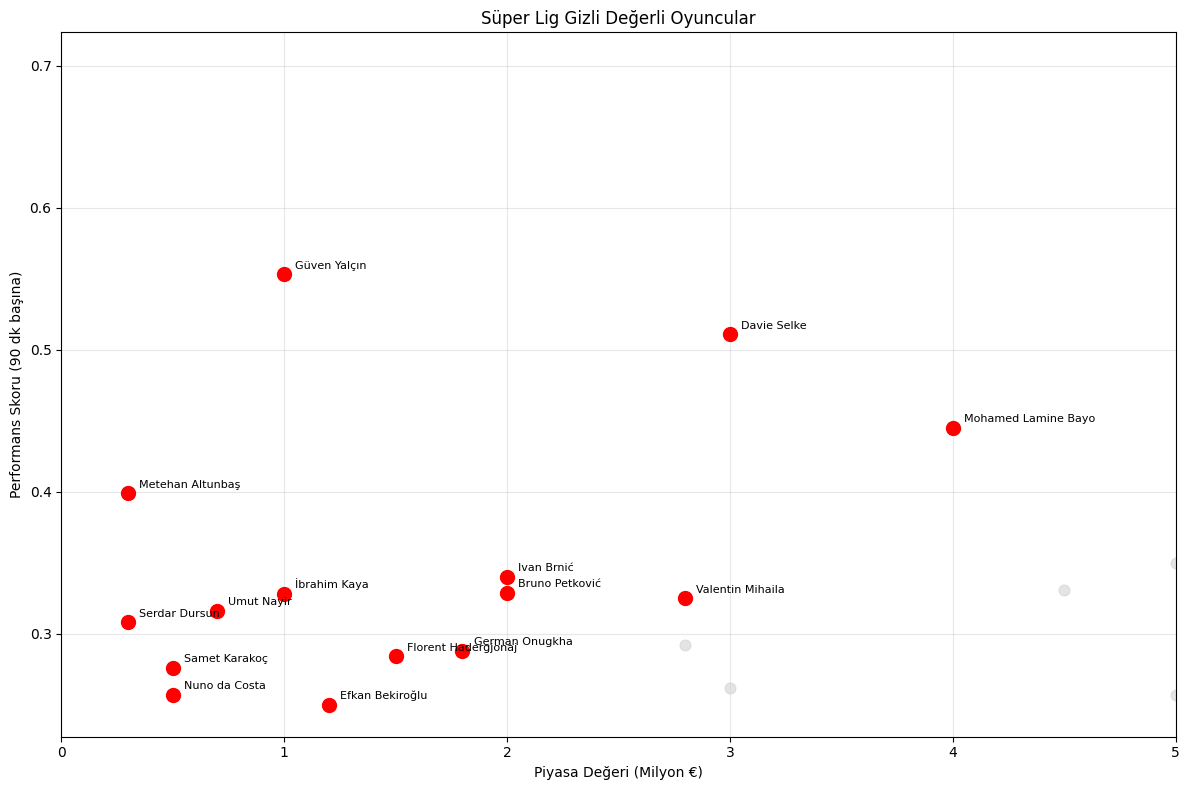

In [38]:
# =============================================================================
# BÖLÜM 6: GÖRSEL
# =============================================================================
 
top15 = df_son.sort_values("Gizli_Deger_Yas", ascending=False).head(15)
 
fig, ax = plt.subplots(figsize=(12, 8))
 
# Tüm oyuncular gri şekilde arka plana ekledim
ax.scatter(
    df_son["Deger_Euro"] / 1_000_000,
    df_son["Performans"],
    color="lightgray", alpha=0.6, s=60, zorder=2
)
 
# Top 15 kırmızı vurgulu noktalar
ax.scatter(
    top15["Deger_Euro"] / 1_000_000,
    top15["Performans"],
    color="red", s=100, zorder=3
)
 
# Oyuncu isimleri
for _, row in top15.iterrows():
    ax.annotate(
        row["Player"],
        (row["Deger_Euro"] / 1_000_000, row["Performans"]),
        textcoords="offset points",
        xytext=(8, 4),
        fontsize=8
    )
 
ax.set_xlabel("Piyasa Değeri (Milyon €)")
ax.set_ylabel("Performans Skoru (90 dk başına)")
ax.set_title("Süper Lig Gizli Değerli Oyuncular")
ax.set_xlim(0, 5)
ax.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig("gizli_deger_grafik.png", dpi=150)
plt.show()